# HEALPix to Polar Stereographic Raster (8 km)

For each cell in an 8 km EPSG:3031 grid, find all HEALPix order-12 cells
whose centers fall within it, then aggregate.

Source resolution ~0.86 km, target 8 km, so ~87 source cells per output pixel.

In [1]:
import warnings
from datetime import timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from mortie._healpix import pix2ang
from obstore.store import S3Store
from pyproj import Transformer
from zarr import config
from zarr.storage import ObjectStore

warnings.filterwarnings("ignore")

## 1. Load zarr and filter to cells with data

In [2]:
S3_BUCKET = "xagg"
S3_PREFIX = "atl06/morton_aggregation.zarr"
CHILD_ORDER = 12
NSIDE = 2 ** CHILD_ORDER  # 4096

config.set({"async.concurrency": 128})
s3_store = S3Store(
    S3_BUCKET,
    prefix=S3_PREFIX,
    region="us-west-2",
    skip_signature=True,
    client_options={"connect_timeout": timedelta(seconds=60)},
    retry_config={
        "max_retries": 2,
        "retry_timeout": timedelta(seconds=5),
        "backoff": {
            "init_backoff": timedelta(seconds=5),
            "max_backoff": timedelta(seconds=30),
            "base": 1.2,
        },
    },
)
store = ObjectStore(store=s3_store, read_only=True)

In [3]:
%%time
# Load raw zarr -- no xdggs decode needed
ds = xr.open_dataset(
    store, engine="zarr", consolidated=True, zarr_format=3,
    group=str(CHILD_ORDER),
)

# Filter to cells with actual observations
has_data = ds["count"].values > 0
cell_ids = ds["cell_ids"].values[has_data]
count = ds["count"].values[has_data].astype(np.float64)
h_mean = ds["h_mean"].values[has_data].astype(np.float64)
h_sigma = ds["h_sigma"].values[has_data].astype(np.float64)
h_min = ds["h_min"].values[has_data].astype(np.float64)
h_max = ds["h_max"].values[has_data].astype(np.float64)
h_variance = ds["h_variance"].values[has_data].astype(np.float64)
h_q25 = ds["h_q25"].values[has_data].astype(np.float64)
h_q50 = ds["h_q50"].values[has_data].astype(np.float64)
h_q75 = ds["h_q75"].values[has_data].astype(np.float64)

print(f"Total cells in zarr: {len(has_data):,}")
print(f"Cells with count > 0: {has_data.sum():,}")
print(f"Cells with count = 0 (discarded): {(~has_data).sum():,}")
print(f"Total observations: {count.sum():.0f}")

Total cells in zarr: 5,447,680
Cells with count > 0: 4,301,176
Cells with count = 0 (discarded): 1,146,504
Total observations: 1309193959
CPU times: user 11.8 s, sys: 4.89 s, total: 16.7 s
Wall time: 13.3 s


## 2. HEALPix cell centers to polar stereographic coordinates

Use mortie's Rust-backed `pix2ang` (returns lon/lat in degrees, NESTED scheme).

In [4]:
%%time
lon, lat = pix2ang(NSIDE, cell_ids.astype(np.int64))

print(f"Lat range: {lat.min():.2f} to {lat.max():.2f}")
print(f"Lon range: {lon.min():.2f} to {lon.max():.2f}")

Lat range: -88.39 to -62.00
Lon range: 0.03 to 359.97
CPU times: user 150 ms, sys: 80.8 ms, total: 230 ms
Wall time: 93.2 ms


In [5]:
%%time
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
x, y = transformer.transform(lon, lat)

print(f"X range: {x.min()/1e3:.0f} to {x.max()/1e3:.0f} km")
print(f"Y range: {y.min()/1e3:.0f} to {y.max()/1e3:.0f} km")

X range: -2599 to 2715 km
Y range: -2203 to 2231 km
CPU times: user 313 ms, sys: 34.9 ms, total: 348 ms
Wall time: 360 ms


## 3. Define output grid and assign source cells to pixels

Change `GRID_SPACING` below to adjust output resolution (e.g., 1000 for 1 km, 8000 for 8 km).

In [6]:
%%time
GRID_SPACING = 8000  # meters — adjust for coarser/finer grids

# Grid extent: 3400 km covers to ~59S
EXTENT = 3_400_000
x_min, x_max = -EXTENT, EXTENT
y_min, y_max = -EXTENT, EXTENT

# Pixel indices for each source cell
ix = np.floor((x - x_min) / GRID_SPACING).astype(np.int64)
iy = np.floor((y - y_min) / GRID_SPACING).astype(np.int64)

nx = int((x_max - x_min) / GRID_SPACING)
ny = int((y_max - y_min) / GRID_SPACING)
n_out = nx * ny

# Keep only source cells whose center falls within the grid
inside = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)

print(f"Output grid: {nx} x {ny} = {n_out:,} pixels at {GRID_SPACING/1e3:.0f} km")
print(f"Source cells inside grid: {inside.sum():,} / {len(inside):,}")
print(f"Source cells outside grid: {(~inside).sum():,}")
print(f"Observations captured: {count[inside].sum():.0f} / {count.sum():.0f} "
      f"({100 * count[inside].sum() / count.sum():.2f}%)")

Output grid: 850 x 850 = 722,500 pixels at 8 km
Source cells inside grid: 4,301,176 / 4,301,176
Source cells outside grid: 0
Observations captured: 1309193959 / 1309193959 (100.00%)
CPU times: user 55.1 ms, sys: 91.5 ms, total: 147 ms
Wall time: 144 ms


In [7]:
# Apply the inside mask and compute flat index
ix = ix[inside]
iy = iy[inside]
flat = (iy * nx + ix).astype(np.int64)

count_in = count[inside]
h_mean_in = h_mean[inside]
h_sigma_in = h_sigma[inside]
h_min_in = h_min[inside]
h_max_in = h_max[inside]
h_variance_in = h_variance[inside]
h_q25_in = h_q25[inside]
h_q50_in = h_q50[inside]
h_q75_in = h_q75[inside]

## 4. Aggregate

- **count**: sum of observation counts
- **h_mean**: weighted mean by nobs: `sum(n_i * h_i) / sum(n_i)`
- **h_sigma**: propagated uncertainty: `sqrt(sum(n_i^2 * sigma_i^2)) / sum(n_i)`
- **h_min**: minimum across source cells
- **h_max**: maximum across source cells
- **h_variance, h_q25, h_q50, h_q75**: weighted mean by nobs

In [8]:
%%time
# --- count: sum ---
count_out = np.bincount(flat, weights=count_in, minlength=n_out)
filled = count_out > 0

# --- weighted means (weight = nobs) using bincount ---
def weighted_mean(values, weights=count_in):
    wsum = np.bincount(flat, weights=values * weights, minlength=n_out)
    result = np.full(n_out, np.nan)
    result[filled] = wsum[filled] / count_out[filled]
    return result

h_mean_out = weighted_mean(h_mean_in)
h_variance_out = weighted_mean(h_variance_in)
h_q25_out = weighted_mean(h_q25_in)
h_q50_out = weighted_mean(h_q50_in)
h_q75_out = weighted_mean(h_q75_in)

# --- sigma: error propagation through weighted mean ---
# sigma_combined = sqrt(sum(n_i^2 * sigma_i^2)) / sum(n_i)
sigma_sq_wsum = np.bincount(flat, weights=count_in**2 * h_sigma_in**2, minlength=n_out)
h_sigma_out = np.full(n_out, np.nan)
h_sigma_out[filled] = np.sqrt(sigma_sq_wsum[filled]) / count_out[filled]

# --- min / max ---
h_min_out = np.full(n_out, np.inf)
np.minimum.at(h_min_out, flat, h_min_in)
h_min_out[~filled] = np.nan

h_max_out = np.full(n_out, -np.inf)
np.maximum.at(h_max_out, flat, h_max_in)
h_max_out[~filled] = np.nan

print(f"Filled pixels: {filled.sum():,} / {n_out:,} ({100 * filled.mean():.1f}%)")
print(f"Mean source cells per filled pixel: {len(flat) / filled.sum():.1f}")

Filled pixels: 208,365 / 722,500 (28.8%)
Mean source cells per filled pixel: 20.6
CPU times: user 126 ms, sys: 78.8 ms, total: 205 ms
Wall time: 201 ms


In [9]:
# Build output dataset
x_centers = np.arange(x_min + GRID_SPACING / 2, x_max, GRID_SPACING)
y_centers = np.arange(y_min + GRID_SPACING / 2, y_max, GRID_SPACING)

ds_out = xr.Dataset(
    {
        "count": (["y", "x"], count_out.reshape(ny, nx).astype(np.int64)),
        "h_mean": (["y", "x"], h_mean_out.reshape(ny, nx).astype(np.float32)),
        "h_sigma": (["y", "x"], h_sigma_out.reshape(ny, nx).astype(np.float32)),
        "h_min": (["y", "x"], h_min_out.reshape(ny, nx).astype(np.float32)),
        "h_max": (["y", "x"], h_max_out.reshape(ny, nx).astype(np.float32)),
        "h_variance": (["y", "x"], h_variance_out.reshape(ny, nx).astype(np.float32)),
        "h_q25": (["y", "x"], h_q25_out.reshape(ny, nx).astype(np.float32)),
        "h_q50": (["y", "x"], h_q50_out.reshape(ny, nx).astype(np.float32)),
        "h_q75": (["y", "x"], h_q75_out.reshape(ny, nx).astype(np.float32)),
    },
    coords={"x": x_centers, "y": y_centers},
    attrs={
        "crs": "EPSG:3031",
        "grid_spacing_m": GRID_SPACING,
        "source": f"s3://{S3_BUCKET}/{S3_PREFIX}",
        "source_grid": f"HEALPix order {CHILD_ORDER} (nside={NSIDE})",
        "method": "binning: healpix cell center in output pixel, nobs-weighted mean",
    },
)
ds_out["x"].attrs = {"units": "m", "standard_name": "projection_x_coordinate"}
ds_out["y"].attrs = {"units": "m", "standard_name": "projection_y_coordinate"}
print(ds_out)

<xarray.Dataset> Size: 29MB
Dimensions:     (y: 850, x: 850)
Coordinates:
  * x           (x) float64 7kB -3.396e+06 -3.388e+06 ... 3.388e+06 3.396e+06
  * y           (y) float64 7kB -3.396e+06 -3.388e+06 ... 3.388e+06 3.396e+06
Data variables:
    count       (y, x) int64 6MB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    h_mean      (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_sigma     (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_min       (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_max       (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_variance  (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_q25       (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_q50       (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
    h_q75       (y, x) float32 3MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    crs:             EPSG:303

## 5. Visualize

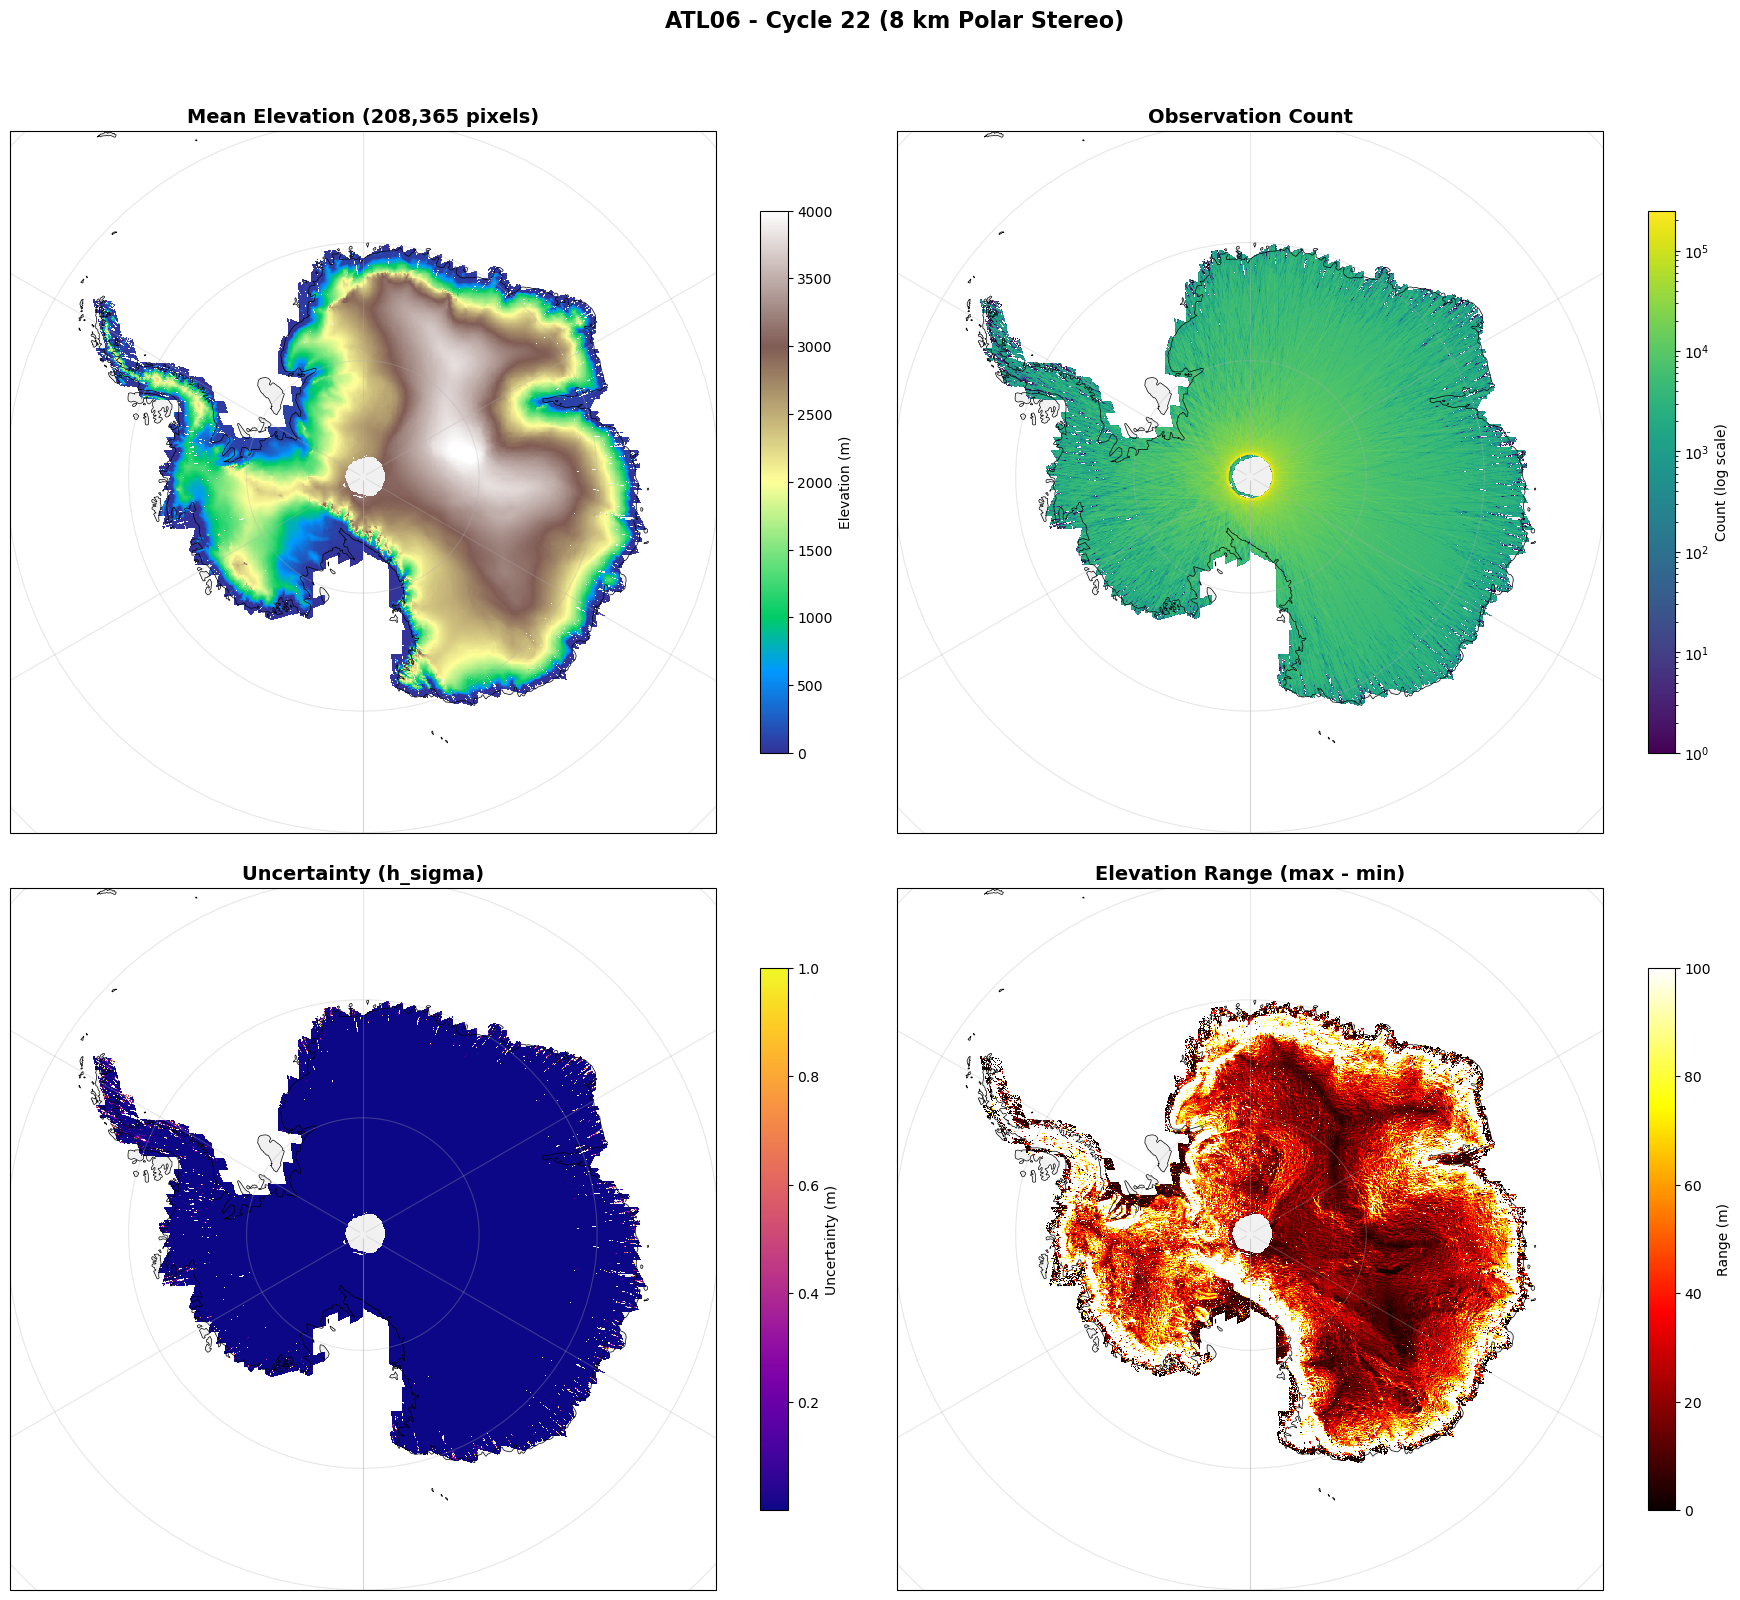

CPU times: user 2.02 s, sys: 178 ms, total: 2.19 s
Wall time: 2.26 s


In [10]:
%%time
proj = ccrs.SouthPolarStereo()
img_extent = [x_min, x_max, y_min, y_max]

fig, axes = plt.subplots(2, 2, figsize=(18, 16), subplot_kw={"projection": proj})
for ax in axes.flat:
    ax.coastlines(resolution="50m", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.gridlines(draw_labels=False, alpha=0.3)
    ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

mask = ds_out["count"].values > 0

# 1. Mean elevation
ax = axes[0, 0]
d = ds_out["h_mean"].values.copy()
d[~mask] = np.nan
im = ax.imshow(d, origin="lower", extent=img_extent, transform=proj,
               cmap="terrain", vmin=0, vmax=4000, interpolation="nearest")
ax.set_title(f"Mean Elevation ({mask.sum():,} pixels)", fontsize=14, weight="bold")
plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)

# 2. Observation count
ax = axes[0, 1]
d = ds_out["count"].values.astype(np.float64)
d[~mask] = np.nan
im = ax.imshow(d, origin="lower", extent=img_extent, transform=proj,
               cmap="viridis", norm=plt.matplotlib.colors.LogNorm(vmin=1),
               interpolation="nearest")
ax.set_title("Observation Count", fontsize=14, weight="bold")
plt.colorbar(im, ax=ax, label="Count (log scale)", shrink=0.7)

# 3. Uncertainty
ax = axes[1, 0]
d = ds_out["h_sigma"].values.copy()
d[~mask] = np.nan
im = ax.imshow(d, origin="lower", extent=img_extent, transform=proj,
               cmap="plasma", vmax=1.0, interpolation="nearest")
ax.set_title("Uncertainty (h_sigma)", fontsize=14, weight="bold")
plt.colorbar(im, ax=ax, label="Uncertainty (m)", shrink=0.7)

# 4. Elevation range
ax = axes[1, 1]
d = ds_out["h_max"].values - ds_out["h_min"].values
d[~mask] = np.nan
im = ax.imshow(d, origin="lower", extent=img_extent, transform=proj,
               cmap="hot", vmax=100, interpolation="nearest")
ax.set_title("Elevation Range (max - min)", fontsize=14, weight="bold")
plt.colorbar(im, ax=ax, label="Range (m)", shrink=0.7)

plt.suptitle("ATL06 - Cycle 22 (8 km Polar Stereo)", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Regional Zoom - West Antarctica

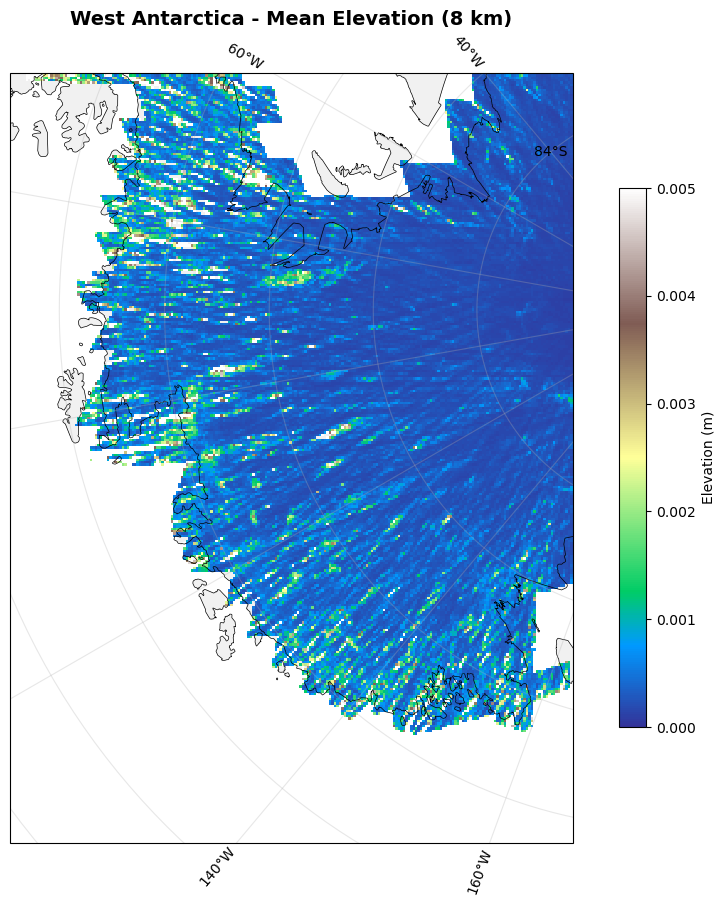

In [11]:
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": proj})
ax.coastlines(resolution="10m", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.gridlines(draw_labels=True, alpha=0.3)
ax.set_extent([-140, -70, -85, -70], crs=ccrs.PlateCarree())

d = ds_out["h_sigma"].values.copy()
d[ds_out["count"].values == 0] = np.nan
im = ax.imshow(d, origin="lower", extent=[x_min, x_max, y_min, y_max],
               transform=proj, cmap="terrain", vmin=0, vmax=.005,
               interpolation="nearest")
plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title("West Antarctica - Mean Elevation (8 km)", fontsize=14, weight="bold")
plt.show()

## 7. Save to Zarr

In [12]:
%%time
output_path = "atl06_polar_stereo_8km.zarr"
ds_out.to_zarr(output_path, mode="w")
print(f"Saved to {output_path}")

Saved to atl06_polar_stereo_8km.zarr
CPU times: user 374 ms, sys: 71 ms, total: 445 ms
Wall time: 243 ms


## 8. Summary

In [13]:
filled = ds_out["count"].values > 0
print(f"Grid: {nx} x {ny} at {GRID_SPACING/1e3:.0f} km (EPSG:3031)")
print(f"Filled pixels: {filled.sum():,} / {n_out:,} ({100*filled.mean():.1f}%)")
print(f"Total observations: {ds_out['count'].values.sum():,}")
print(f"\nElevation (h_mean):")
print(f"  Min:  {np.nanmin(ds_out['h_mean'].values):.2f} m")
print(f"  Max:  {np.nanmax(ds_out['h_mean'].values):.2f} m")
print(f"  Mean: {np.nanmean(ds_out['h_mean'].values):.2f} m")

Grid: 850 x 850 at 8 km (EPSG:3031)
Filled pixels: 208,365 / 722,500 (28.8%)
Total observations: 1,309,193,959

Elevation (h_mean):
  Min:  -351.95 m
  Max:  4090.73 m
  Mean: 1958.54 m
